# hn15~24 통합 EDA + 간기능이상 (데이터 불균형 보완)
성인(19세 이상) | 전처리 전 원본 기준

- **hn22~24**: 전체 인구 데이터
- **hn18~21**: 당뇨 유병 행만 추가 (클래스 불균형 보완)

**타겟 코드북**: 1=유병 / 8(해당없음)=정상 / 0·9=제외

> ✅ v3 변경사항: `USE_COLS_SAS`에 간기능 변수 추가 (`HE_ast`, `HE_alt`, `HE_ggt`, `HE_hepaB`, `HE_hepaC`, `HE_ALP`, `HE_wc`, `HE_glu`, `HE_chol`, `HE_TG`, `HE_HDL_st2`, `HE_LDL_drct`) + 간기능이상유병 타겟 파생 + v3 CSV 저장

## 0. 데이터 로드

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from matplotlib import rc
from scipy import stats
import pyreadstat
import warnings
warnings.filterwarnings("ignore")

matplotlib.rcParams["axes.unicode_minus"] = False
rc("font", family="AppleGothic")

# ── 컬럼 선택 (v3: 간기능 변수 추가) ─────────────────────────────
USE_COLS_SAS = [
    "ID", "sex", "age", "occp", "HE_ht", "HE_wt", "HE_BMI", "sm_presnt",
    "BD1_11", "BD2_1",
    "HE_HPfh1", "HE_HPfh2", "HE_HPfh3",
    "HE_DMfh1", "HE_DMfh2", "HE_DMfh3",
    "HE_HLfh1", "HE_HLfh2", "HE_HLfh3",
    "BE3_31", "BE5_1",
    "DI1_pr", "DI1_2",   # 고혈압 진단/간질환 진단 — rename에서 분리
    "DE1_pr", "DI2_pr",  # 당뇨, 이상지질혈증
    "HE_obe",
    # ── 간기능이상용 추가 ──────────────────────
    "HE_ast", "HE_alt", "HE_ggt",   # 간수치 (HE_ggt는 일부 연도 없을 수 있음)
    "HE_hepaB", "HE_hepaC",          # 바이러스 간염
    "HE_ALP",                        # 담즙정체 (HE_ggt 없는 연도 보완)
    "HE_wc",                         # 복부비만
    "HE_glu", "HE_chol", "HE_TG", "HE_HDL_st2", "HE_LDL_drct",  # 대사
]

COL_RENAME = {
    "sex": "성별", "age": "나이", "occp": "직업",
    "HE_ht": "키", "HE_wt": "체중", "HE_BMI": "BMI",
    "sm_presnt": "현재흡연", "BD1_11": "음주빈도", "BD2_1": "음주량",
    "HE_HPfh1": "고혈압가족력_부", "HE_HPfh2": "고혈압가족력_모", "HE_HPfh3": "고혈압가족력_형제",
    "HE_DMfh1": "당뇨가족력_부",   "HE_DMfh2": "당뇨가족력_모",   "HE_DMfh3": "당뇨가족력_형제",
    "HE_HLfh1": "고지혈증가족력_부","HE_HLfh2": "고지혈증가족력_모","HE_HLfh3": "고지혈증가족력_형제",
    "BE3_31": "걷기일수", "BE5_1": "근력운동일수",
    "DI1_pr": "고혈압유병",          # 고혈압 진단 여부
    "DI1_2":  "간질환진단",          # ⚠️ v3 분리: 간질환 관련 코드
    "DE1_pr": "당뇨유병", "DI2_pr": "이상지질혈증유병",
    "HE_obe": "비만단계",
    "HE_ast": "AST", "HE_alt": "ALT",
    "HE_ggt": "GGT", "HE_ALP": "ALP",
    "HE_hepaB": "B형간염항원", "HE_hepaC": "C형간염항체",
    "HE_wc": "허리둘레",
    "HE_glu": "공복혈당", "HE_chol": "총콜레스테롤",
    "HE_TG": "중성지방", "HE_HDL_st2": "HDL", "HE_LDL_drct": "LDL",
}

INT_COLS = [
    "성별", "나이", "직업", "현재흡연", "음주빈도", "음주량", "걷기일수", "근력운동일수",
    "고혈압유병", "당뇨유병", "이상지질혈증유병", "비만단계", "간질환진단",
    "B형간염항원", "C형간염항체",
    "고혈압가족력_부", "고혈압가족력_모", "고혈압가족력_형제",
    "당뇨가족력_부", "당뇨가족력_모", "당뇨가족력_형제",
    "고지혈증가족력_부", "고지혈증가족력_모", "고지혈증가족력_형제",
]

DATA_DIR = "/Users/admin/PycharmProjects/AH_03_03/etc/ml/ai_worker/data"

# ── hn22~24: 전체 인구 로드 ────────────────────────────────────────
PATHS = {
    2022: f"{DATA_DIR}/hn22_all.sas7bdat",
    2023: f"{DATA_DIR}/hn23_all.sas7bdat",
    2024: f"{DATA_DIR}/hn24_all.sas7bdat",
}

import os

dfs = []
for year, path in PATHS.items():
    if not os.path.exists(path):
        print(f"hn{year} 파일 없음 — skip: {path}")
        continue
    # 해당 연도에 실제 존재하는 컬럼만 list로 전달
    _, meta = pyreadstat.read_sas7bdat(path, metadataonly=True)
    avail_sas = [c for c in USE_COLS_SAS if c in meta.column_names]
    df_tmp, _ = pyreadstat.read_sas7bdat(path, usecols=avail_sas)
    df_tmp = df_tmp.rename(columns=COL_RENAME)
    for c in INT_COLS:
        if c in df_tmp.columns:
            df_tmp[c] = pd.to_numeric(df_tmp[c], errors="coerce")
    df_tmp = df_tmp[df_tmp["나이"] >= 19].reset_index(drop=True)
    df_tmp = df_tmp.drop(columns=["ID"], errors="ignore")
    df_tmp["연도"] = year
    dfs.append(df_tmp)
    print(f"hn{year} 로드 완료 | shape: {df_tmp.shape}")

if not dfs:
    raise FileNotFoundError(f"SAS 파일을 하나도 찾을 수 없습니다. DATA_DIR 경로를 확인하세요: {DATA_DIR}")

df_main = pd.concat(dfs, ignore_index=True)
for col in ["고혈압유병", "당뇨유병", "이상지질혈증유병"]:
    df_main[col] = df_main[col].map({1.0:1, 1:1, 8.0:0, 8:0})

# ── hn15~21: 당뇨 유병 행만 추가 (SAS 원본) ─────────────────────
DM_PATHS = {
    2021: f"{DATA_DIR}/hn21_all.sas7bdat",
    2020: f"{DATA_DIR}/hn20_all.sas7bdat",
    2019: f"{DATA_DIR}/hn19_all.sas7bdat",
    2018: f"{DATA_DIR}/hn18_all.sas7bdat",
    2017: f"{DATA_DIR}/hn17_all.sas7bdat",
    2016: f"{DATA_DIR}/hn16_all.sas7bdat",
    2015: f"{DATA_DIR}/hn15_all.sas7bdat",
}

dfs_dm = []
for year, path in DM_PATHS.items():
    if not os.path.exists(path):
        print(f"hn{year} 파일 없음 — skip: {path}")
        continue
    _, meta = pyreadstat.read_sas7bdat(path, metadataonly=True)
    avail_sas = [c for c in USE_COLS_SAS if c in meta.column_names]
    df_tmp, _ = pyreadstat.read_sas7bdat(path, usecols=avail_sas)
    df_tmp = df_tmp.rename(columns=COL_RENAME)
    for c in INT_COLS:
        if c in df_tmp.columns:
            df_tmp[c] = pd.to_numeric(df_tmp[c], errors="coerce")
    df_tmp = df_tmp[df_tmp["나이"] >= 19].reset_index(drop=True)
    df_tmp = df_tmp.drop(columns=["ID"], errors="ignore")
    df_tmp["연도"] = year

    # 타겟 이진화 먼저
    for col in ["당뇨유병", "고혈압유병", "이상지질혈증유병"]:
        if col in df_tmp.columns:
            df_tmp[col] = df_tmp[col].map({1.0:1, 1:1, 8.0:0, 8:0})

    # ── 연도별 유병 필터 조건 ──────────────────────────────────────
    # hn21: 당뇨 유병 OR 이상지질혈증 유병 행 추가
    # hn15~20: 당뇨 유병 행만 추가
    if year == 2021:
        # hn21: 당뇨 OR 이상지질혈증 유병 행 추가
        if "당뇨유병" in df_tmp.columns:
            cond_dm = df_tmp["당뇨유병"] == 1
        else:
            cond_dm = pd.Series(False, index=df_tmp.index)

        if "이상지질혈증유병" in df_tmp.columns:
            cond_dysl = df_tmp["이상지질혈증유병"] == 1
        else:
            cond_dysl = pd.Series(False, index=df_tmp.index)

        df_tmp = df_tmp[cond_dm | cond_dysl].reset_index(drop=True)
        print(f"hn{year} 당뇨+이상지질혈증 유병 추가 | shape: {df_tmp.shape}")
    else:
        # hn15~20: 당뇨 유병 행만 추가
        if "당뇨유병" in df_tmp.columns:
            df_tmp = df_tmp[df_tmp["당뇨유병"] == 1].reset_index(drop=True)
        print(f"hn{year} 당뇨 유병 추가 | shape: {df_tmp.shape}")

    dfs_dm.append(df_tmp)

# ── 최종 통합 ─────────────────────────────────────────────────────
if dfs_dm:
    df_dm_add = pd.concat(dfs_dm, ignore_index=True)
    df = pd.concat([df_main, df_dm_add], ignore_index=True)
else:
    print("⚠️ hn15~21 파일 없음 — hn22~24만으로 진행")
    df = df_main.copy()

print(f"\n통합 shape: {df.shape}")
print(f"연도별 샘플: {df['연도'].value_counts().sort_index().to_dict()}")
print("\n=== 기존 타겟 불균형 확인 ===")
for col in ["고혈압유병", "당뇨유병", "이상지질혈증유병"]:
    vc = df[col].value_counts()
    n0, n1 = vc.get(0,0), vc.get(1,0)
    print(f"  {col}: 정상 {n0:,} / 유병 {n1:,} / 불균형 1:{n0/max(n1,1):.1f}")
df.head()

hn2022 로드 완료 | shape: (5322, 36)
hn2023 로드 완료 | shape: (5907, 36)
hn2024 로드 완료 | shape: (6033, 37)
hn2021 당뇨+이상지질혈증 유병 추가 | shape: (1494, 36)
hn2020 당뇨 유병 추가 | shape: (661, 36)
hn2019 당뇨 유병 추가 | shape: (605, 36)
hn2018 당뇨 유병 추가 | shape: (572, 36)
hn2017 당뇨 유병 추가 | shape: (579, 36)
hn2016 당뇨 유병 추가 | shape: (607, 36)
hn2015 당뇨 유병 추가 | shape: (475, 36)

통합 shape: (22255, 37)
연도별 샘플: {2015: 475, 2016: 607, 2017: 579, 2018: 572, 2019: 605, 2020: 661, 2021: 1494, 2022: 5322, 2023: 5907, 2024: 6033}

=== 기존 타겟 불균형 확인 ===
  고혈압유병: 정상 14,162 / 유병 7,774 / 불균형 1:1.8
  당뇨유병: 정상 15,880 / 유병 6,318 / 불균형 1:2.5
  이상지질혈증유병: 정상 14,615 / 유병 6,942 / 불균형 1:2.1


,성별,나이,직업,고혈압유병,간질환진단,이상지질혈증유병,당뇨유병,음주빈도,음주량,현재흡연,...,총콜레스테롤,HDL,중성지방,LDL,AST,ALT,B형간염항원,C형간염항체,연도,ALP
0,2.0,56.0,7.0,1.0,1.0,0.0,0.0,1.0,8.0,0.0,...,199.0,56.0,181.0,122.0,22.0,16.0,0.0,0.0,2022,NaN
1,1.0,30.0,3.0,0.0,8.0,0.0,0.0,3.0,2.0,0.0,...,122.0,48.0,63.0,63.0,28.0,18.0,0.0,0.0,2022,NaN
2,2.0,25.0,7.0,0.0,8.0,0.0,0.0,4.0,1.0,0.0,...,202.0,75.0,53.0,124.0,17.0,15.0,0.0,0.0,2022,NaN
3,1.0,66.0,7.0,0.0,8.0,1.0,0.0,3.0,2.0,0.0,...,136.0,47.0,123.0,74.0,20.0,15.0,0.0,0.0,2022,NaN
4,2.0,62.0,6.0,0.0,8.0,1.0,0.0,2.0,1.0,0.0,...,149.0,53.0,110.0,82.0,26.0,23.0,0.0,0.0,2022,NaN


## 1. 기본 통계량

In [22]:
cont_cols = ["나이", "키", "체중", "BMI"]
summary = pd.DataFrame({
    "N":        df[cont_cols].count(),
    "결측수":    df[cont_cols].isnull().sum(),
    "결측률(%)": (df[cont_cols].isnull().sum()/len(df)*100).round(1),
    "평균":      df[cont_cols].mean().round(2),
    "중앙값":    df[cont_cols].median().round(2),
    "표준편차":  df[cont_cols].std().round(2),
    "최솟값":    df[cont_cols].min().round(2),
    "최댓값":    df[cont_cols].max().round(2),
    "왜도":      df[cont_cols].skew().round(3),
    "첨도":      df[cont_cols].kurt().round(3),
})
print("=== 연속형 변수 기술통계 ===")
print(summary.T)

=== 연속형 변수 기술통계 ===
               나이          키         체중        BMI
N       22255.000  21863.000  22126.000  21858.000
결측수         0.000    392.000    129.000    397.000
결측률(%)      0.000      1.800      0.600      1.800
평균         56.500    162.770     64.710     24.320
중앙값        59.000    162.400     63.100     24.030
표준편차       16.560      9.360     12.990      3.740
최솟값        19.000    127.900     25.000     12.070
최댓값        80.000    194.000    147.000     48.680
왜도         -0.463      0.098      0.850      0.744
첨도         -0.761     -0.407      1.417      1.540


## 2. 연도별 샘플 분포

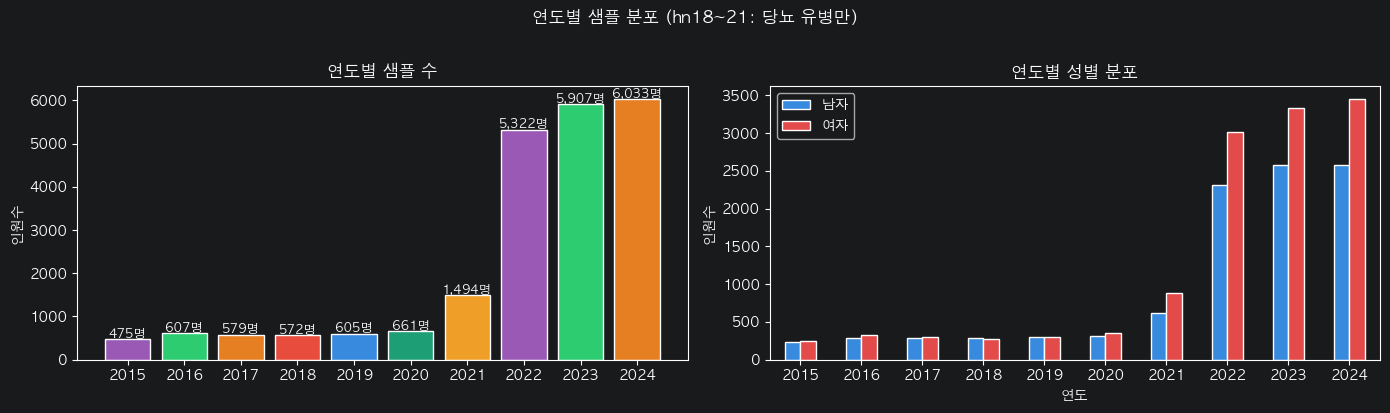

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

vc = df["연도"].value_counts().sort_index()
colors_yr = ["#9B59B6","#2ECC71","#E67E22","#E74C3C","#378ADD","#1D9E75","#EF9F27"]
axes[0].bar(vc.index.astype(str), vc.values, color=colors_yr[:len(vc)], edgecolor="white")
axes[0].set_title("연도별 샘플 수"); axes[0].set_ylabel("인원수")
for i, (idx, val) in enumerate(vc.items()):
    axes[0].text(i, val+30, f"{val:,}명", ha="center", fontsize=9)

gender_ct = df.groupby(["연도","성별"]).size().unstack(fill_value=0)
gender_ct.columns = ["남자","여자"]
gender_ct.plot(kind="bar", ax=axes[1], color=["#378ADD","#E24B4A"], edgecolor="white", rot=0)
axes[1].set_title("연도별 성별 분포"); axes[1].set_ylabel("인원수"); axes[1].legend()

plt.suptitle("연도별 샘플 분포 (hn18~21: 당뇨 유병만)", fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

## 3. Y값(타겟) 분포
> **0=정상 / 1=유병 / NaN=제외**
>
> ⚠️ hn18~21은 당뇨 유병 행만 포함 → 연도별 분포는 hn22~24만 해석

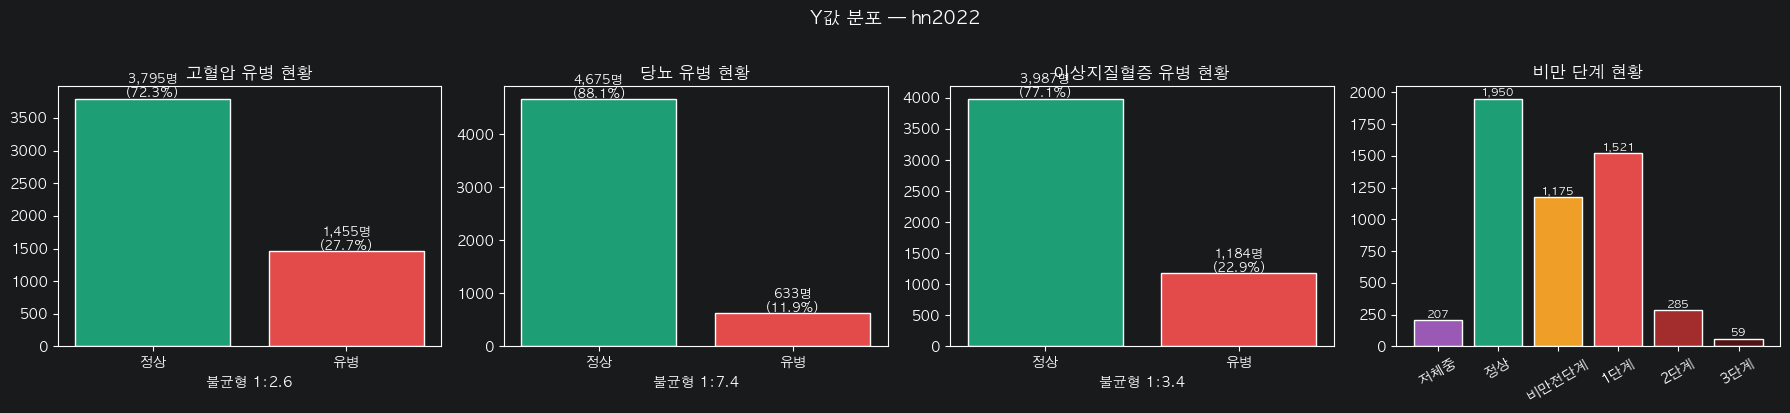

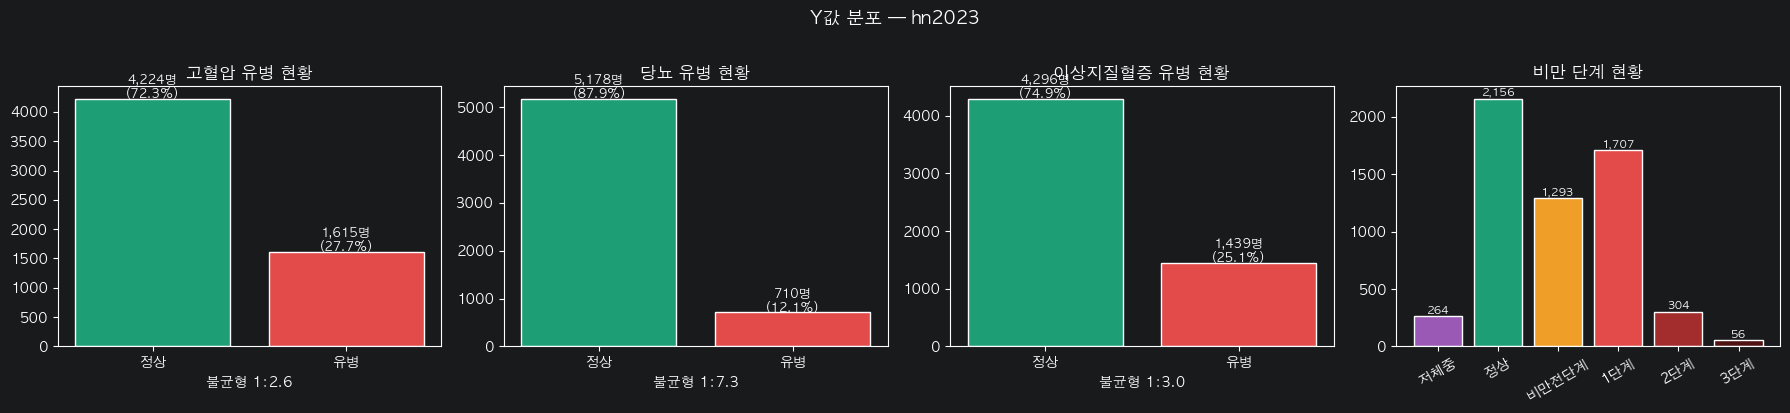

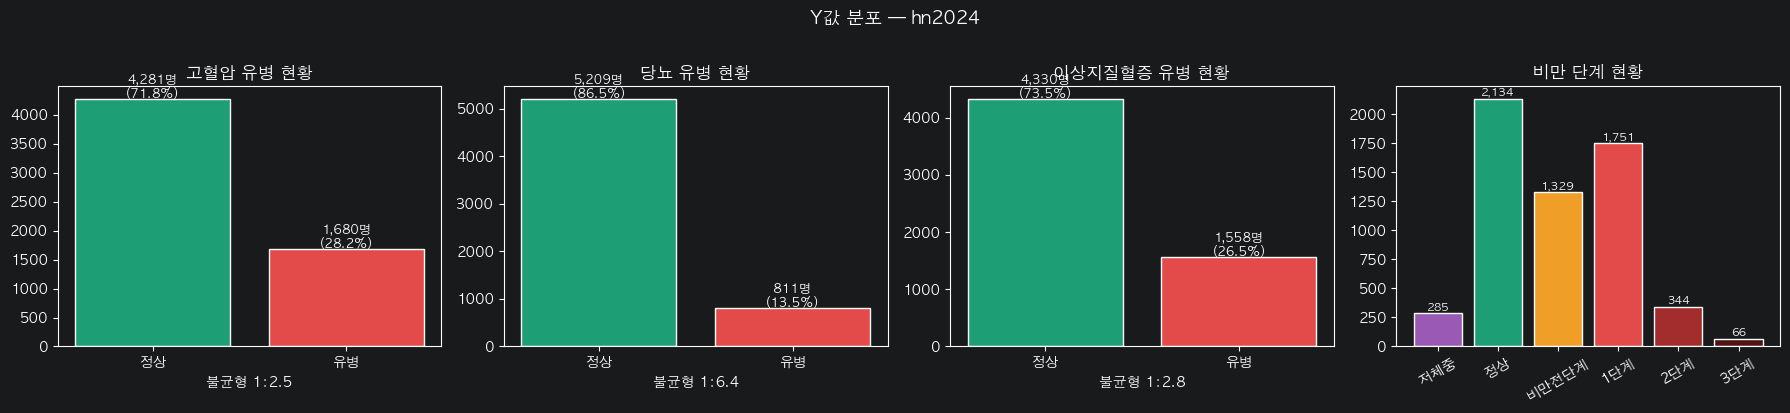

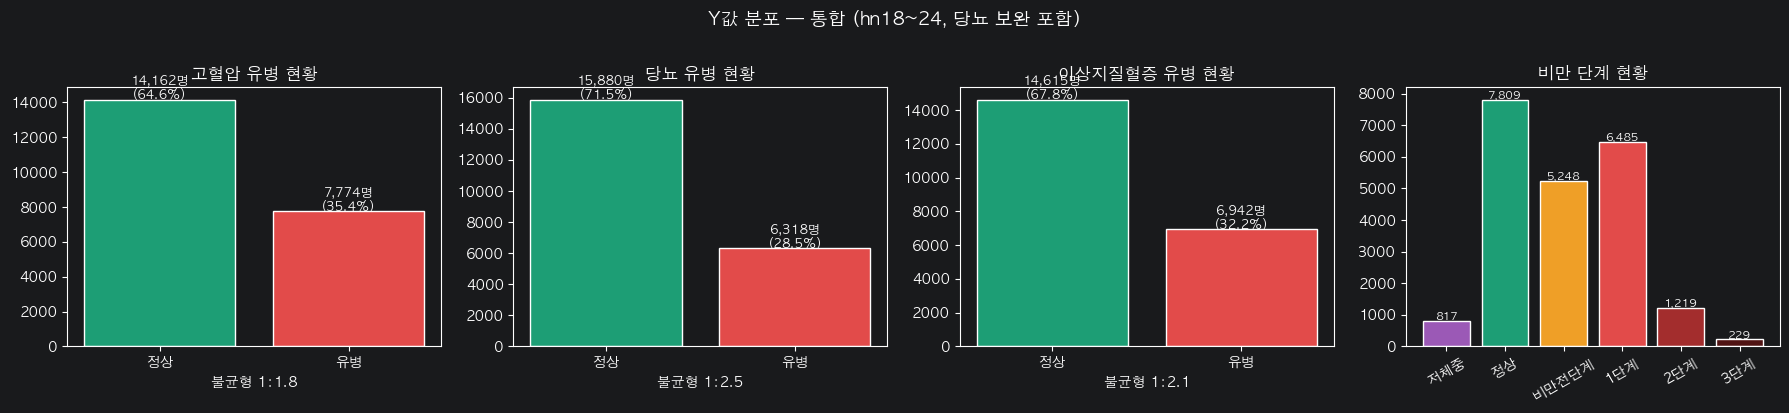

In [24]:
def plot_y_dist(data, title_suffix=""):
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    for ax, col, title in zip(
        axes[:3],
        ["고혈압유병","당뇨유병","이상지질혈증유병"],
        ["고혈압","당뇨","이상지질혈증"]
    ):
        vc = data[col].value_counts().sort_index()
        n_total = vc.sum()
        bars = ax.bar(["정상","유병"], vc.values, color=["#1D9E75","#E24B4A"], edgecolor="white")
        ax.set_title(f"{title} 유병 현황")
        for bar, val in zip(bars, vc.values):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                    f"{val:,}명\n({val/n_total*100:.1f}%)", ha="center", fontsize=9)
        n1=vc.get(1,0); n0=vc.get(0,0)
        ax.set_xlabel(f"불균형 1:{n0/n1:.1f}" if n1>0 else "")
    obe = data["비만단계"].value_counts().sort_index().dropna()
    obe_labels = {1:"저체중",2:"정상",3:"비만전단계",4:"1단계",5:"2단계",6:"3단계"}
    obe.index = [obe_labels.get(int(i), str(i)) for i in obe.index]
    axes[3].bar(obe.index, obe.values,
                color=["#9B59B6","#1D9E75","#EF9F27","#E24B4A","#A32D2D","#501313"],
                edgecolor="white")
    axes[3].set_title("비만 단계 현황")
    axes[3].tick_params(axis="x", rotation=30)
    for i, v in enumerate(obe.values):
        axes[3].text(i, v+20, f"{v:,}", ha="center", fontsize=8)
    plt.suptitle(f"Y값 분포 {title_suffix}", fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()

for year in [2022, 2023, 2024]:
    plot_y_dist(df[df["연도"]==year], f"— hn{year}")
plot_y_dist(df, "— 통합 (hn18~24, 당뇨 보완 포함)")

## 4. 연속형 변수 분포

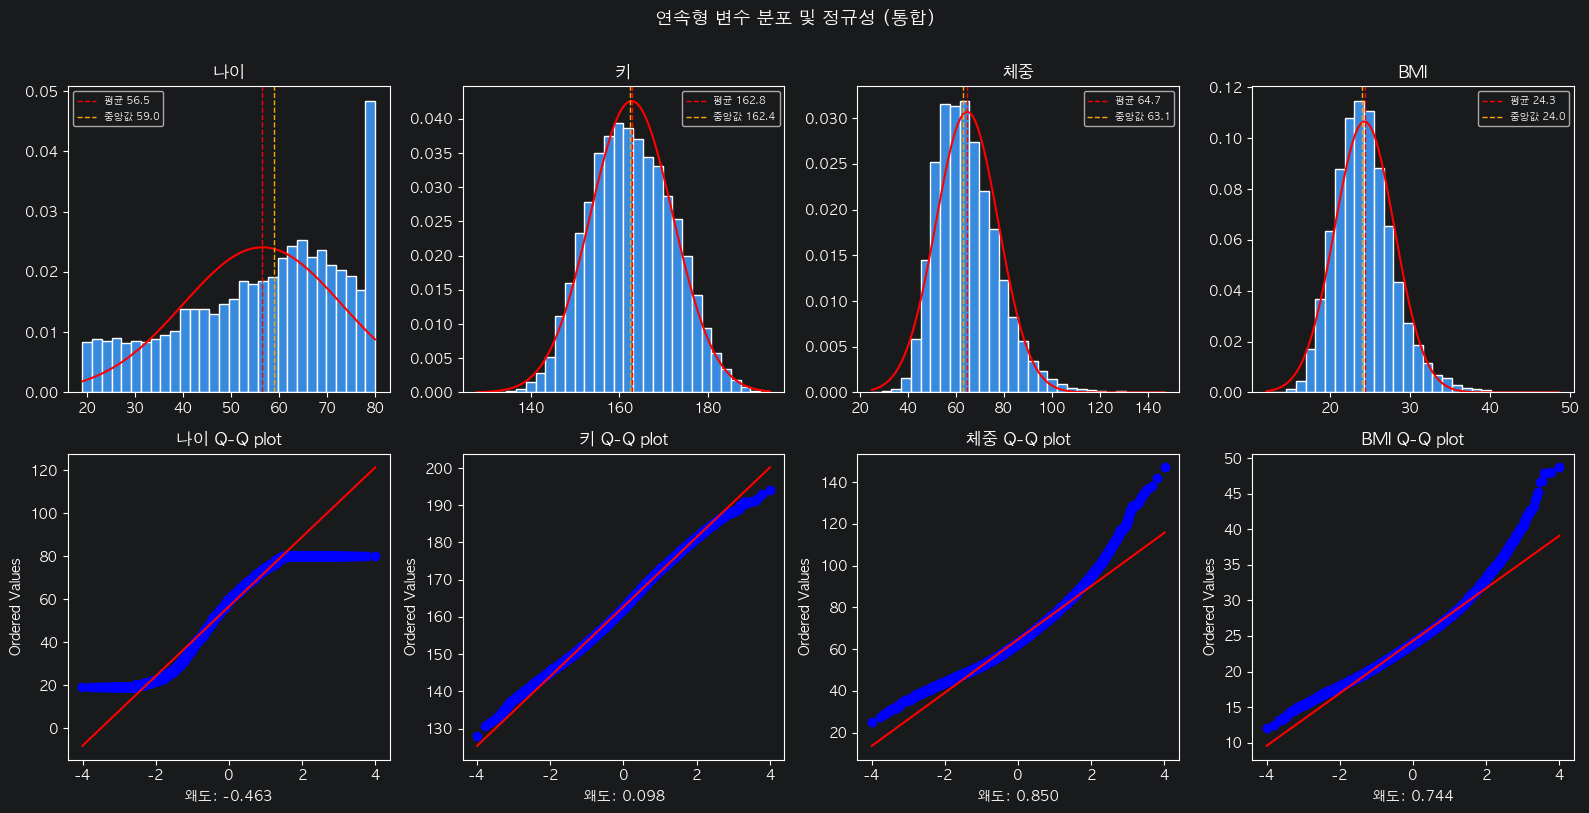

In [25]:
cont_cols = ["나이","키","체중","BMI"]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for j, col in enumerate(cont_cols):
    data = df[col].dropna()
    mu, std = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 100)
    axes[0][j].hist(data, bins=30, color="#378ADD", edgecolor="white", density=True)
    axes[0][j].plot(x, stats.norm.pdf(x, mu, std), "r-", lw=1.5)
    axes[0][j].axvline(mu, color="red", ls="--", lw=1, label=f"평균 {mu:.1f}")
    axes[0][j].axvline(data.median(), color="orange", ls="--", lw=1, label=f"중앙값 {data.median():.1f}")
    axes[0][j].set_title(col); axes[0][j].legend(fontsize=7)
    stats.probplot(data, dist="norm", plot=axes[1][j])
    axes[1][j].set_title(f"{col} Q-Q plot")
    axes[1][j].set_xlabel(f"왜도: {data.skew():.3f}")

plt.suptitle("연속형 변수 분포 및 정규성 (통합)", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## 5. 범주형 변수 분포

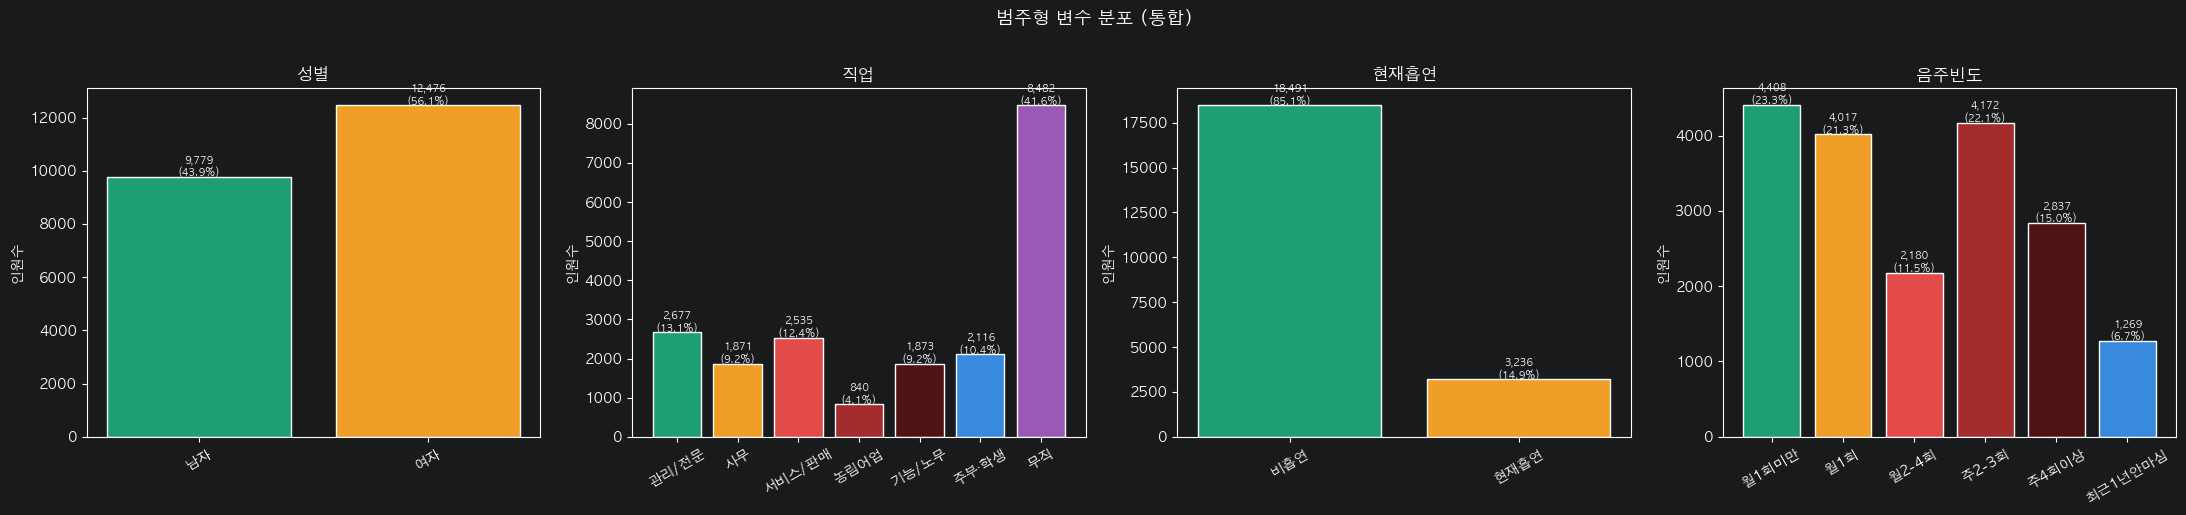

In [26]:
cat_cols = {
    "성별":     {1:"남자", 2:"여자"},
    "직업":     {1:"관리/전문",2:"사무",3:"서비스/판매",4:"농림어업",5:"기능/노무",6:"주부·학생",7:"무직"},
    "현재흡연": {0:"비흡연", 1:"현재흡연"},
    "음주빈도": {0:"비음주",1:"월1회미만",2:"월1회",3:"월2-4회",4:"주2-3회",5:"주4회이상",6:"최근1년안마심"},
}
colors = ["#1D9E75","#EF9F27","#E24B4A","#A32D2D","#501313","#378ADD","#9B59B6","#2ECC71"]
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, (col, labels) in zip(axes, cat_cols.items()):
    vc = df[col].value_counts(dropna=True).sort_index()
    vc = vc[vc.index.isin(labels.keys())]
    new_index = [labels.get(i, str(i)) for i in vc.index]
    pct = (vc/vc.sum()*100).round(1)
    bars = ax.bar(new_index, vc.values, color=colors[:len(vc)], edgecolor="white")
    ax.set_title(col, fontsize=12); ax.set_ylabel("인원수"); ax.tick_params(axis="x", rotation=30)
    for bar, val, p in zip(bars, vc.values, pct.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                f"{val:,}\n({p}%)", ha="center", fontsize=7)

plt.suptitle("범주형 변수 분포 (통합)", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## 6. Y값별 연속형 비교 (boxplot)

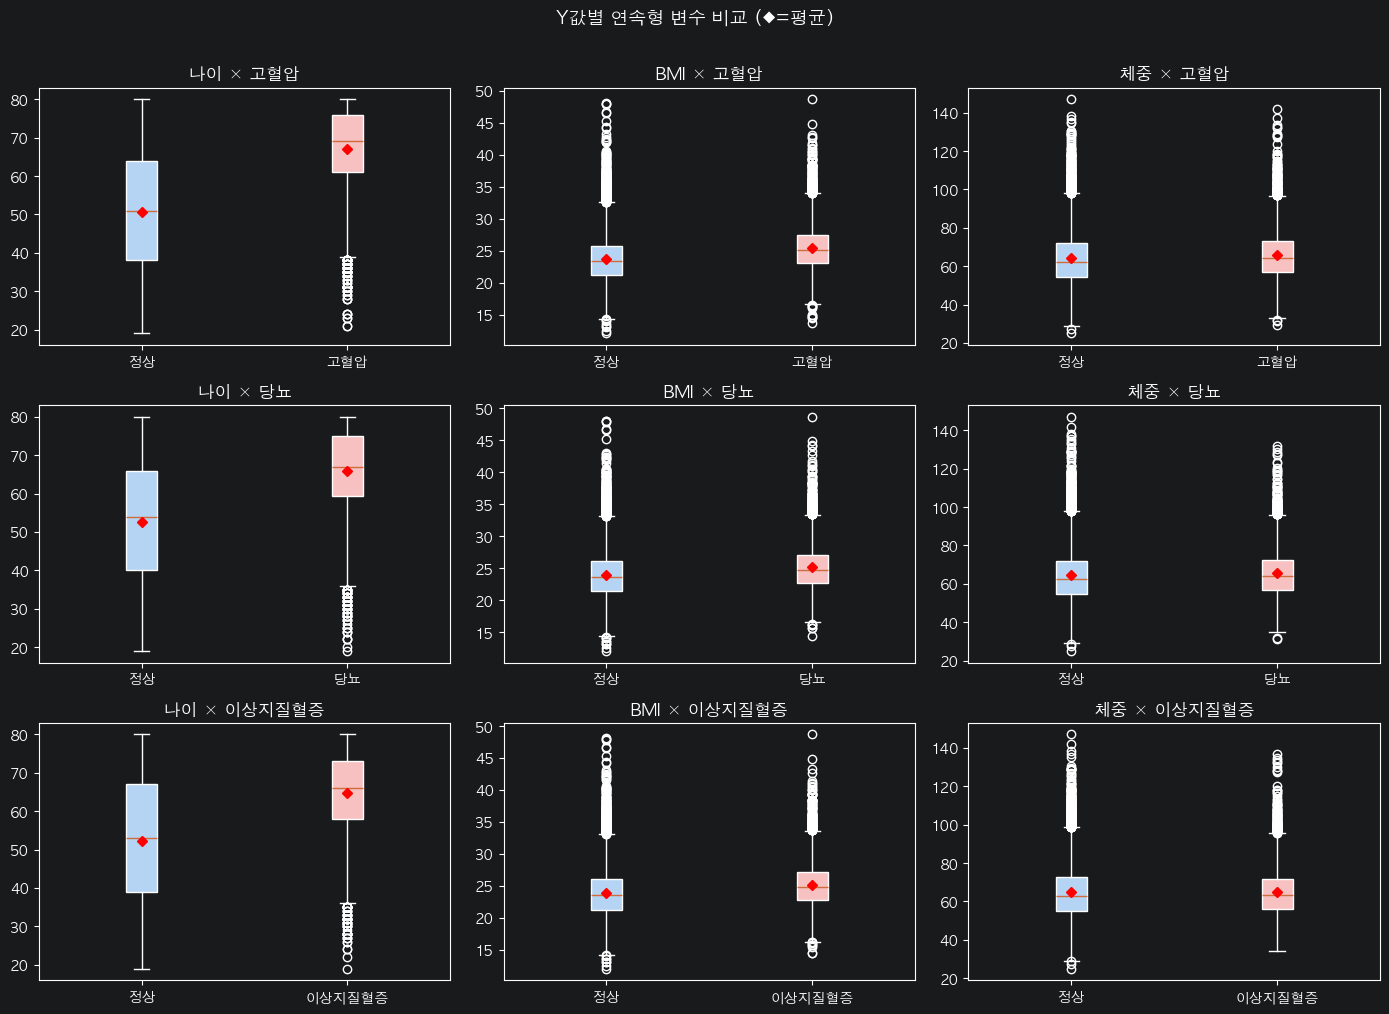

In [27]:
y_vars = {"고혈압유병":"고혈압", "당뇨유병":"당뇨", "이상지질혈증유병":"이상지질혈증"}
x_vars = ["나이","BMI","체중"]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for i, (y_col, y_label) in enumerate(y_vars.items()):
    for j, x_col in enumerate(x_vars):
        d0 = df[df[y_col]==0][x_col].dropna()
        d1 = df[df[y_col]==1][x_col].dropna()
        bp = axes[i][j].boxplot([d0,d1], labels=["정상",y_label], patch_artist=True)
        bp["boxes"][0].set_facecolor("#B5D4F4")
        bp["boxes"][1].set_facecolor("#F7C1C1")
        axes[i][j].set_title(f"{x_col} × {y_label}")
        for k, d in enumerate([d0,d1]):
            axes[i][j].plot(k+1, d.mean(), "D", color="red", ms=5, zorder=5)

plt.suptitle("Y값별 연속형 변수 비교 (◆=평균)", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## 7. 결측률 분석

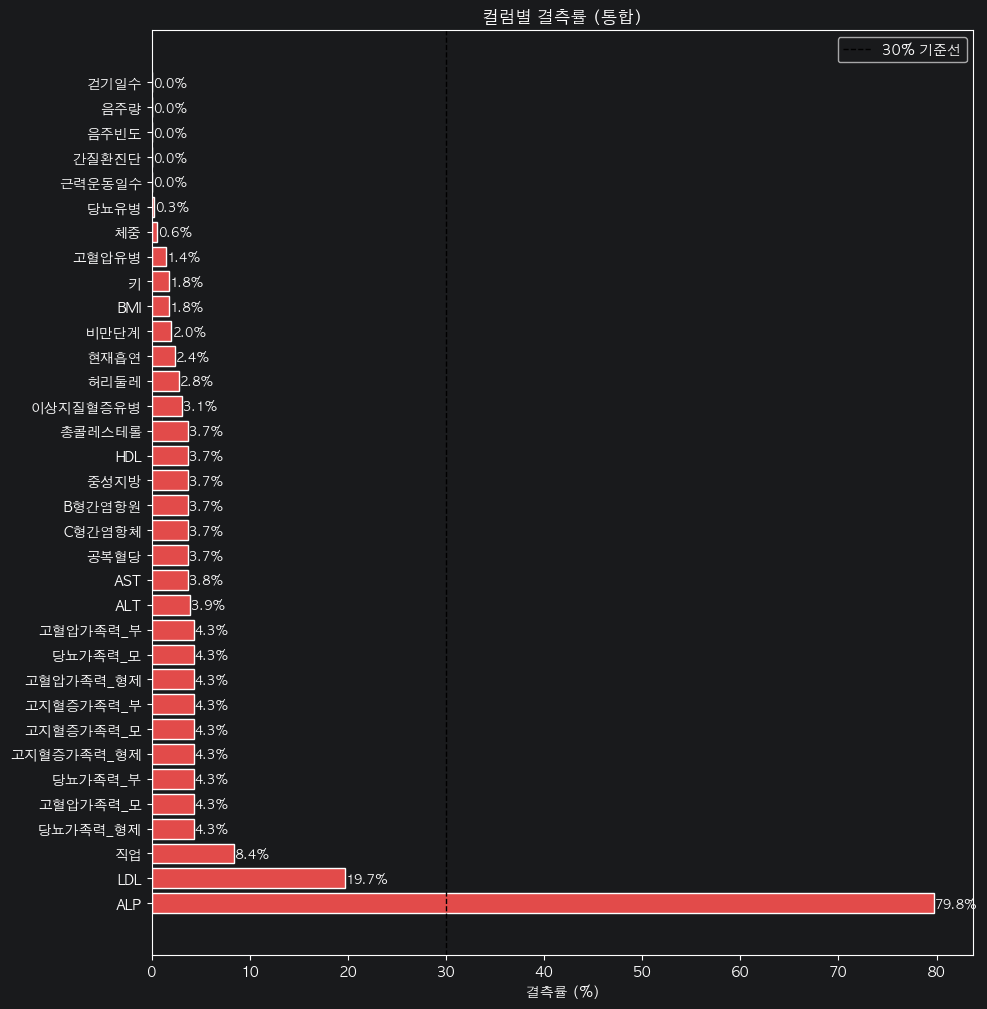

=== 결측률 상세 ===
ALP           79.77
LDL           19.73
직업             8.36
당뇨가족력_형제       4.29
고혈압가족력_모       4.29
당뇨가족력_부        4.29
고지혈증가족력_형제     4.29
고지혈증가족력_모      4.29
고지혈증가족력_부      4.29
고혈압가족력_형제      4.29
당뇨가족력_모        4.29
고혈압가족력_부       4.29
ALT            3.90
AST            3.75
공복혈당           3.73
C형간염항체         3.73
B형간염항원         3.73
중성지방           3.73
HDL            3.73
총콜레스테롤         3.73
이상지질혈증유병       3.14
허리둘레           2.78
현재흡연           2.37
비만단계           2.01
BMI            1.78
키              1.76
고혈압유병          1.43
체중             0.58
당뇨유병           0.26
근력운동일수         0.02
간질환진단          0.02
음주빈도           0.02
음주량            0.02
걷기일수           0.02
dtype: float64


In [28]:
miss_pct = (df.isnull().sum()/len(df)*100).round(2)
miss_pct = miss_pct[miss_pct>0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, max(5, len(miss_pct)*0.3)))
bars = ax.barh(miss_pct.index, miss_pct.values, color="#E24B4A", edgecolor="white")
ax.axvline(30, color="black", linestyle="--", lw=1, label="30% 기준선")
ax.set_xlabel("결측률 (%)"); ax.set_title("컬럼별 결측률 (통합)")
ax.legend()
for bar, val in zip(bars, miss_pct.values):
    ax.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)
plt.tight_layout(); plt.show()
print("=== 결측률 상세 ===")
print(miss_pct)

## 8. 가족력 보유율

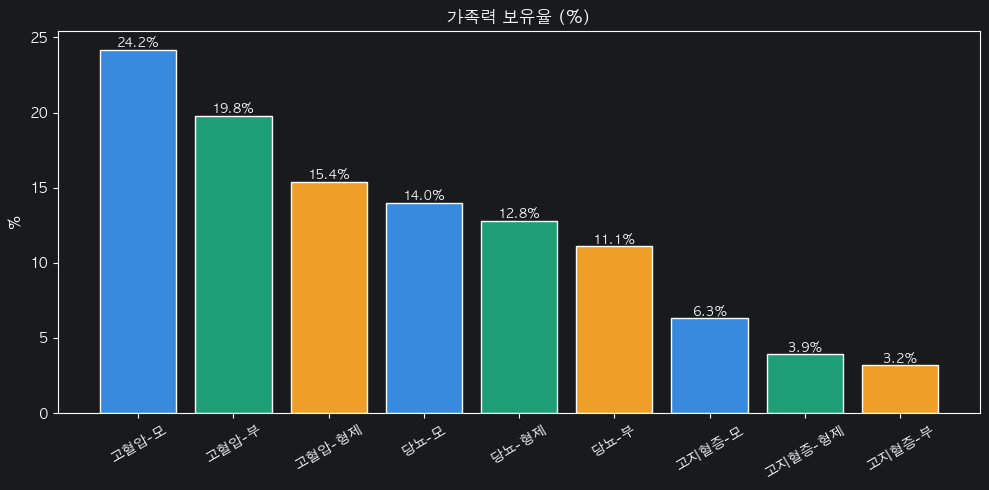

In [29]:
fh_cols = {
    "고혈압가족력_부":"고혈압-부","고혈압가족력_모":"고혈압-모","고혈압가족력_형제":"고혈압-형제",
    "당뇨가족력_부":"당뇨-부","당뇨가족력_모":"당뇨-모","당뇨가족력_형제":"당뇨-형제",
    "고지혈증가족력_부":"고지혈증-부","고지혈증가족력_모":"고지혈증-모","고지혈증가족력_형제":"고지혈증-형제",
}
fh_rate = {}
for col, label in fh_cols.items():
    vc = df[col].value_counts(dropna=True)
    n1 = vc.get(1.0, vc.get(1, 0))
    fh_rate[label] = round(n1/vc.sum()*100, 1) if vc.sum()>0 else 0

fh_series = pd.Series(fh_rate).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(fh_series.index, fh_series.values,
              color=["#378ADD","#1D9E75","#EF9F27"]*3, edgecolor="white")
ax.set_title("가족력 보유율 (%)"); ax.set_ylabel("%"); ax.tick_params(axis="x", rotation=30)
for bar, val in zip(bars, fh_series.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, f"{val}%", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

## 9. 연도별 유병률 추이
> ⚠️ hn18~21은 당뇨 유병만 포함 → hn22~24 추이만 해석 권장

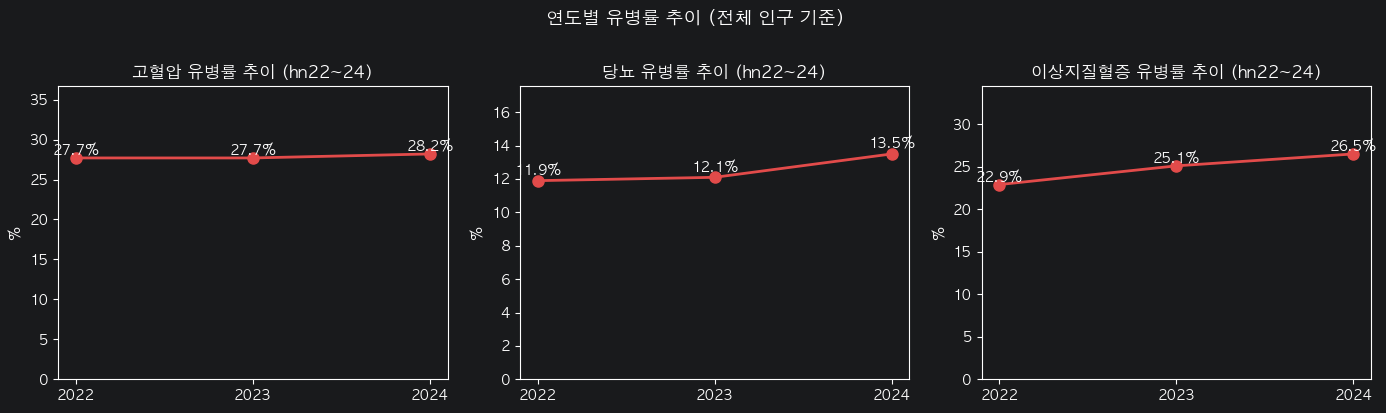

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
y_info = [("고혈압유병","고혈압"),("당뇨유병","당뇨"),("이상지질혈증유병","이상지질혈증")]

df_trend_base = df[df["연도"].isin([2022, 2023, 2024])]

for ax, (col, label) in zip(axes, y_info):
    trend_vals = {}
    for yr in [2022, 2023, 2024]:
        col_data = df_trend_base[df_trend_base["연도"] == yr][col]
        n_pos   = (col_data == 1).sum()
        n_valid = col_data.notna().sum()
        trend_vals[yr] = round(n_pos / n_valid * 100, 1) if n_valid > 0 else 0.0

    trend_index  = list(trend_vals.keys())
    trend_values = list(trend_vals.values())

    ax.plot(trend_index, trend_values, "o-", color="#E24B4A", lw=2, ms=8)
    ax.set_title(f"{label} 유병률 추이 (hn22~24)")
    ax.set_ylabel("%")
    ax.set_xticks(trend_index)
    for x_val, y_val in zip(trend_index, trend_values):
        ax.text(x_val, y_val + 0.3, f"{y_val:.1f}%", ha="center", fontsize=10)
    ax.set_ylim(0, max(trend_values) * 1.3 if trend_values else 1)

plt.suptitle("연도별 유병률 추이 (전체 인구 기준)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 10. 상관관계 히트맵

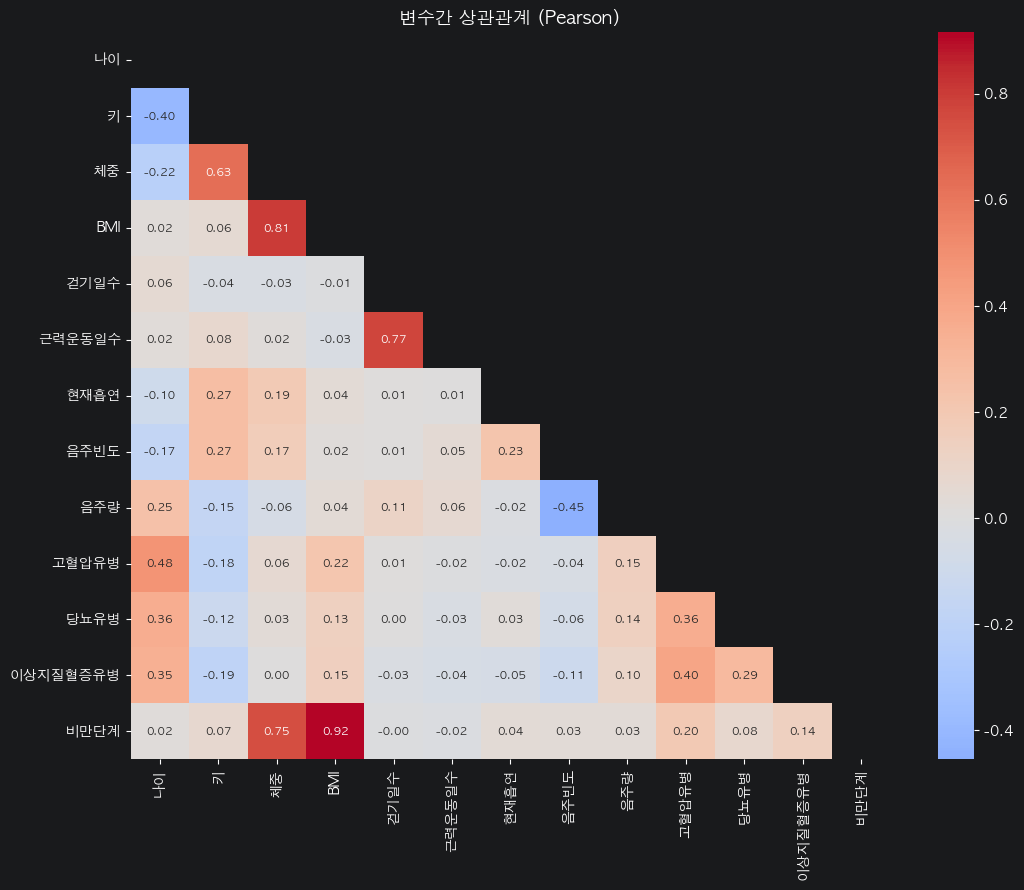

In [31]:
corr_cols = ["나이","키","체중","BMI","걷기일수","근력운동일수",
             "현재흡연","음주빈도","음주량",
             "고혈압유병","당뇨유병","이상지질혈증유병","비만단계"]

df_corr = df[corr_cols].copy()
df_corr["음주빈도"] = df_corr["음주빈도"].where(~df_corr["음주빈도"].isin([8,9]), other=np.nan)

corr = df_corr.corr()
fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, annot_kws={"size":8})
ax.set_title("변수간 상관관계 (Pearson)", fontsize=13)
plt.tight_layout(); plt.show()

---
## 11. 간기능이상 타겟 파생
> **서비스 스크리닝 목적** — 생활습관 개선 권고용 (Recall 우선)
>
> **파생 기준 (복합 OR)**
> - AST > 40 U/L
> - ALT > 40 U/L
> - GGT > 60 U/L (없으면 ALP > 120 U/L 대체)
> - B형간염 표면항원 양성
> - C형간염 항체 양성
> - 간질환 진단 이력 (DI1_2 코드 기반)

In [32]:
# 간 관련 변수 존재 여부 체크
check_vars = {
    "AST":      "AST > 40 (간세포 손상)",
    "ALT":      "ALT > 40 (간 특이적)",
    "GGT":      "GGT > 60 (담즙정체/음주)",
    "ALP":      "ALP > 120 (GGT 없는 연도 보완)",
    "B형간염항원": "B형간염 표면항원 양성",
    "C형간염항체": "C형간염 항체 양성",
    "간질환진단":  "간질환 의사 진단 이력",
}
print("=" * 55)
print(f"{'변수명':<14} {'설명':<26} 존재여부")
print("=" * 55)
for var, desc in check_vars.items():
    status = "✅ 있음" if var in df.columns else "❌ 없음"
    print(f"{var:<14} {desc:<28} {status}")
print("=" * 55)

변수명            설명                         존재여부
AST            AST > 40 (간세포 손상)            ✅ 있음
ALT            ALT > 40 (간 특이적)             ✅ 있음
GGT            GGT > 60 (담즙정체/음주)           ❌ 없음
ALP            ALP > 120 (GGT 없는 연도 보완)     ✅ 있음
B형간염항원         B형간염 표면항원 양성                 ✅ 있음
C형간염항체         C형간염 항체 양성                   ✅ 있음
간질환진단          간질환 의사 진단 이력                 ✅ 있음


In [33]:
# ── 타겟 파생 ─────────────────────────────────────────────────
cond_map = {}
if "AST"       in df.columns: cond_map["AST>40"]     = df["AST"]       > 40
if "ALT"       in df.columns: cond_map["ALT>40"]     = df["ALT"]       > 40
if "GGT"       in df.columns: cond_map["GGT>60"]     = df["GGT"]       > 60
elif "ALP"     in df.columns: cond_map["ALP>120"]    = df["ALP"]       > 120  # GGT 없을 때 대체
if "B형간염항원" in df.columns: cond_map["HBsAg양성"] = df["B형간염항원"] == 1
if "C형간염항체" in df.columns: cond_map["HCV양성"]   = df["C형간염항체"] == 1
if "간질환진단"  in df.columns: cond_map["간질환진단"]  = df["간질환진단"]  == 1

if not cond_map:
    raise ValueError("⚠️ 파생 가능한 변수 없음 — 섹션 0 USE_COLS_SAS 확인")

combined = list(cond_map.values())[0]
for c in list(cond_map.values())[1:]:
    combined = combined | c
df["간기능이상유병"] = combined.astype(int)

# 조건별 기여도
print("조건별 해당자 수:")
for name, cond in cond_map.items():
    n = int(cond.sum())
    print(f"  {name:<12}: {n:,}명 ({n/len(df)*100:.1f}%)")

vc = df["간기능이상유병"].value_counts().sort_index()
n0, n1 = vc.get(0,0), vc.get(1,0)
print(f"\n[간기능이상유병] 정상={n0:,} / 이상={n1:,}")
print(f"양성률: {n1/(n0+n1)*100:.1f}% | 불균형 1:{n0/max(n1,1):.1f}")

조건별 해당자 수:
  AST>40      : 1,139명 (5.1%)
  ALT>40      : 1,905명 (8.6%)
  ALP>120     : 118명 (0.5%)
  HBsAg양성     : 562명 (2.5%)
  HCV양성       : 189명 (0.8%)
  간질환진단       : 7,457명 (33.5%)

[간기능이상유병] 정상=12,974 / 이상=9,281
양성률: 41.7% | 불균형 1:1.4


## 12. 간기능이상 — 타겟 분포 시각화

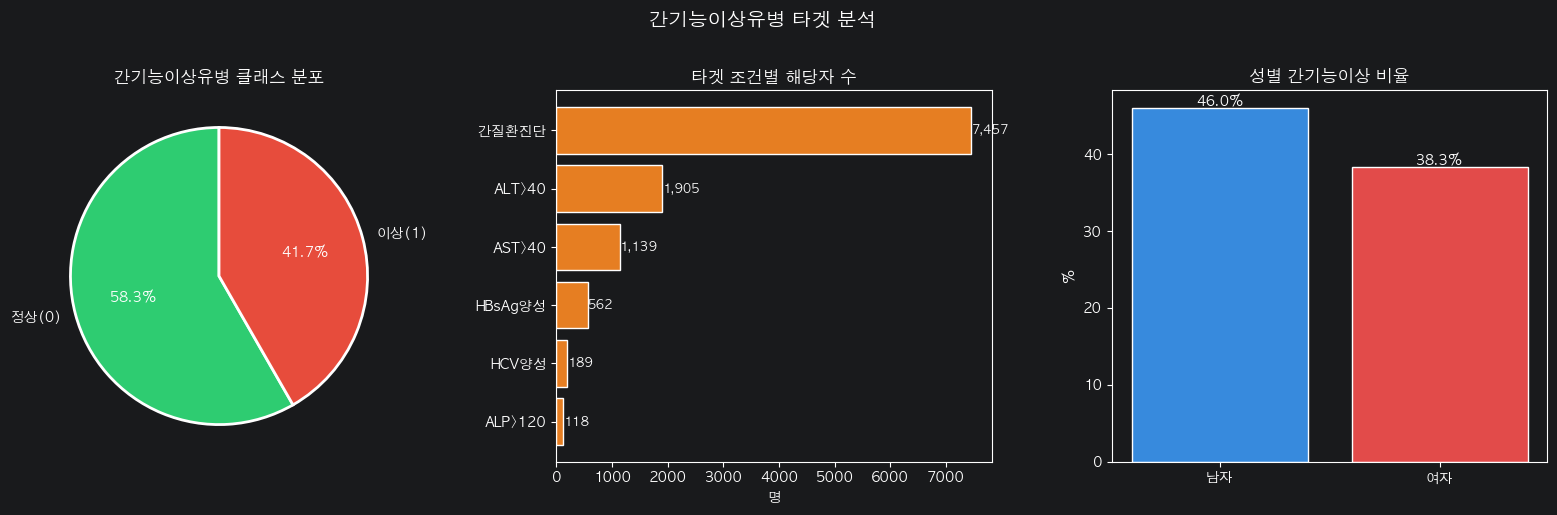

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1) 클래스 분포 파이
vc = df["간기능이상유병"].value_counts().sort_index()
axes[0].pie(vc.values, labels=["정상(0)","이상(1)"], autopct="%1.1f%%",
            colors=["#2ECC71","#E74C3C"], startangle=90,
            wedgeprops={"edgecolor":"white","linewidth":2})
axes[0].set_title("간기능이상유병 클래스 분포")

# 2) 조건별 기여도
contrib = {name: int(cond.sum()) for name, cond in cond_map.items()}
contrib_s = pd.Series(contrib).sort_values(ascending=True)
axes[1].barh(contrib_s.index, contrib_s.values, color="#E67E22", edgecolor="white")
axes[1].set_title("타겟 조건별 해당자 수"); axes[1].set_xlabel("명")
for i, (idx, val) in enumerate(contrib_s.items()):
    axes[1].text(val+5, i, f"{val:,}", va="center", fontsize=9)

# 3) 성별 비율
if "성별" in df.columns:
    cross = df.groupby("성별")["간기능이상유병"].mean() * 100
    labels = {1:"남자", 2:"여자"}
    cross.index = [labels.get(i, str(i)) for i in cross.index]
    axes[2].bar(cross.index, cross.values, color=["#378ADD","#E24B4A"], edgecolor="white")
    axes[2].set_title("성별 간기능이상 비율"); axes[2].set_ylabel("%")
    for i, (idx, val) in enumerate(cross.items()):
        axes[2].text(i, val+0.2, f"{val:.1f}%", ha="center", fontsize=10)

plt.suptitle("간기능이상유병 타겟 분석", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

## 13. 간기능이상 — 핵심 수치 분포 (정상 vs 이상)

=== 정상 vs 이상 기초 통계 ===
[AST] 정상 — 평균:20.2 중앙:19.0 | 이상 — 평균:28.8 중앙:24.0
[ALT] 정상 — 평균:17.8 중앙:16.0 | 이상 — 평균:29.8 중앙:22.0
[ALP] 정상 — 평균:69.0 중앙:68.0 | 이상 — 평균:76.2 중앙:72.0


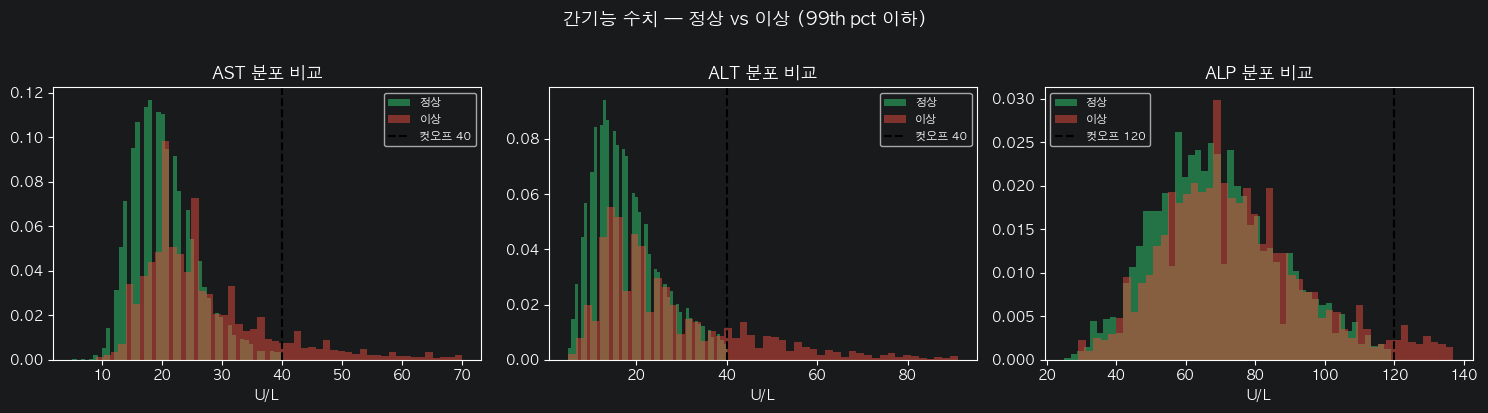

In [35]:
enzyme_vars = [v for v in ["AST","ALT","GGT","ALP"] if v in df.columns]
cutoffs = {"AST":40, "ALT":40, "GGT":60, "ALP":120}

if enzyme_vars:
    fig, axes = plt.subplots(1, len(enzyme_vars), figsize=(5*len(enzyme_vars), 4))
    if len(enzyme_vars) == 1: axes = [axes]

    for ax, var in zip(axes, enzyme_vars):
        cap = df[var].quantile(0.99)
        for label, color, name in [(0,"#2ECC71","정상"),(1,"#E74C3C","이상")]:
            data = df[df["간기능이상유병"]==label][var].dropna()
            data = data[data <= cap]
            ax.hist(data, bins=50, alpha=0.5, color=color, label=name, density=True)
        ax.axvline(cutoffs[var], color="black", linestyle="--", lw=1.5,
                   label=f"컷오프 {cutoffs[var]}")
        ax.set_title(f"{var} 분포 비교"); ax.set_xlabel("U/L"); ax.legend(fontsize=8)

    # 기초 통계
    print("=== 정상 vs 이상 기초 통계 ===")
    for var in enzyme_vars:
        d0 = df[df["간기능이상유병"]==0][var].dropna()
        d1 = df[df["간기능이상유병"]==1][var].dropna()
        print(f"[{var}] 정상 — 평균:{d0.mean():.1f} 중앙:{d0.median():.1f} | "
              f"이상 — 평균:{d1.mean():.1f} 중앙:{d1.median():.1f}")

    plt.suptitle("간기능 수치 — 정상 vs 이상 (99th pct 이하)", fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()

## 14. 간기능이상 — 연령대/BMI/음주 교차 분석

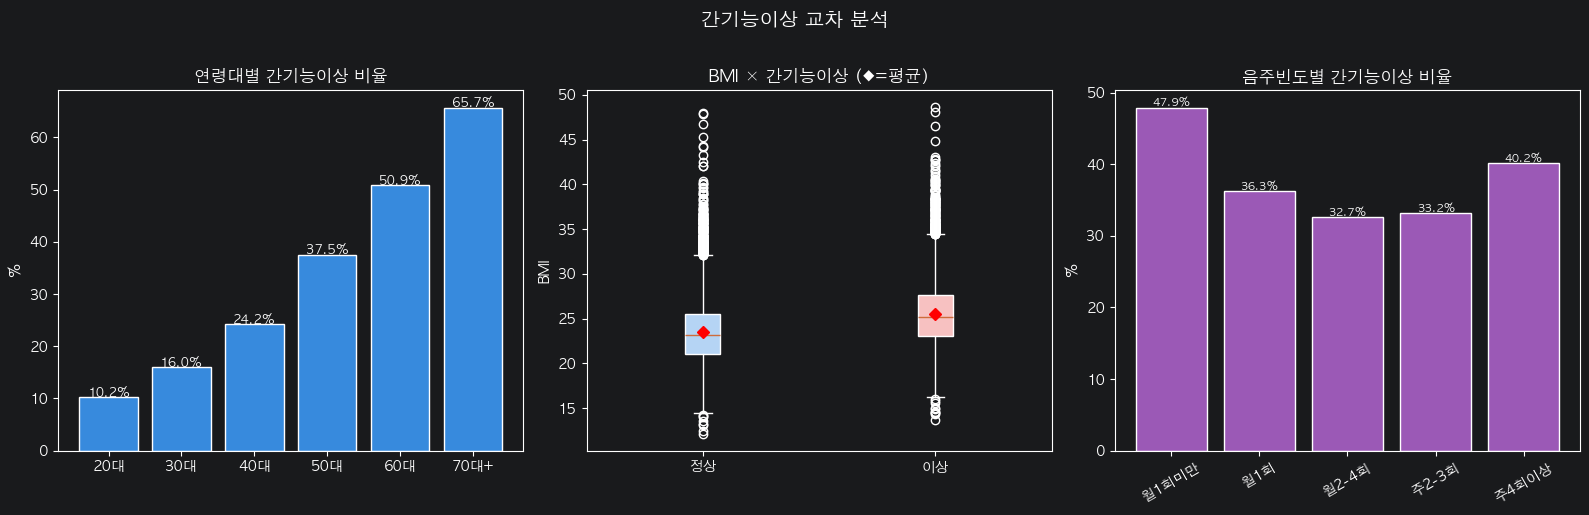

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1) 연령대별
if "나이" in df.columns:
    df["연령대"] = pd.cut(df["나이"], bins=[18,29,39,49,59,69,120],
                        labels=["20대","30대","40대","50대","60대","70대+"])
    age_rate = df.groupby("연령대", observed=True)["간기능이상유병"].mean() * 100
    axes[0].bar(age_rate.index.astype(str), age_rate.values, color="#378ADD", edgecolor="white")
    axes[0].set_title("연령대별 간기능이상 비율"); axes[0].set_ylabel("%")
    for i, val in enumerate(age_rate.values):
        axes[0].text(i, val+0.2, f"{val:.1f}%", ha="center", fontsize=9)

# 2) BMI boxplot
if "BMI" in df.columns:
    d0 = df[df["간기능이상유병"]==0]["BMI"].dropna()
    d1 = df[df["간기능이상유병"]==1]["BMI"].dropna()
    bp = axes[1].boxplot([d0,d1], labels=["정상","이상"], patch_artist=True)
    bp["boxes"][0].set_facecolor("#B5D4F4"); bp["boxes"][1].set_facecolor("#F7C1C1")
    for k, d in enumerate([d0,d1]):
        axes[1].plot(k+1, d.mean(), "D", color="red", ms=6, zorder=5)
    axes[1].set_title("BMI × 간기능이상 (◆=평균)"); axes[1].set_ylabel("BMI")

# 3) 음주빈도별
if "음주빈도" in df.columns:
    drink_labels = {0:"비음주",1:"월1회미만",2:"월1회",3:"월2-4회",4:"주2-3회",5:"주4회이상"}
    df_d = df[df["음주빈도"].isin(drink_labels.keys())].copy()
    drink_rate = df_d.groupby("음주빈도")["간기능이상유병"].mean() * 100
    drink_rate.index = [drink_labels[i] for i in drink_rate.index]
    axes[2].bar(drink_rate.index, drink_rate.values, color="#9B59B6", edgecolor="white")
    axes[2].set_title("음주빈도별 간기능이상 비율"); axes[2].set_ylabel("%")
    axes[2].tick_params(axis="x", rotation=30)
    for i, val in enumerate(drink_rate.values):
        axes[2].text(i, val+0.1, f"{val:.1f}%", ha="center", fontsize=8)

plt.suptitle("간기능이상 교차 분석", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

## 15. 간기능이상 — 상관관계 히트맵

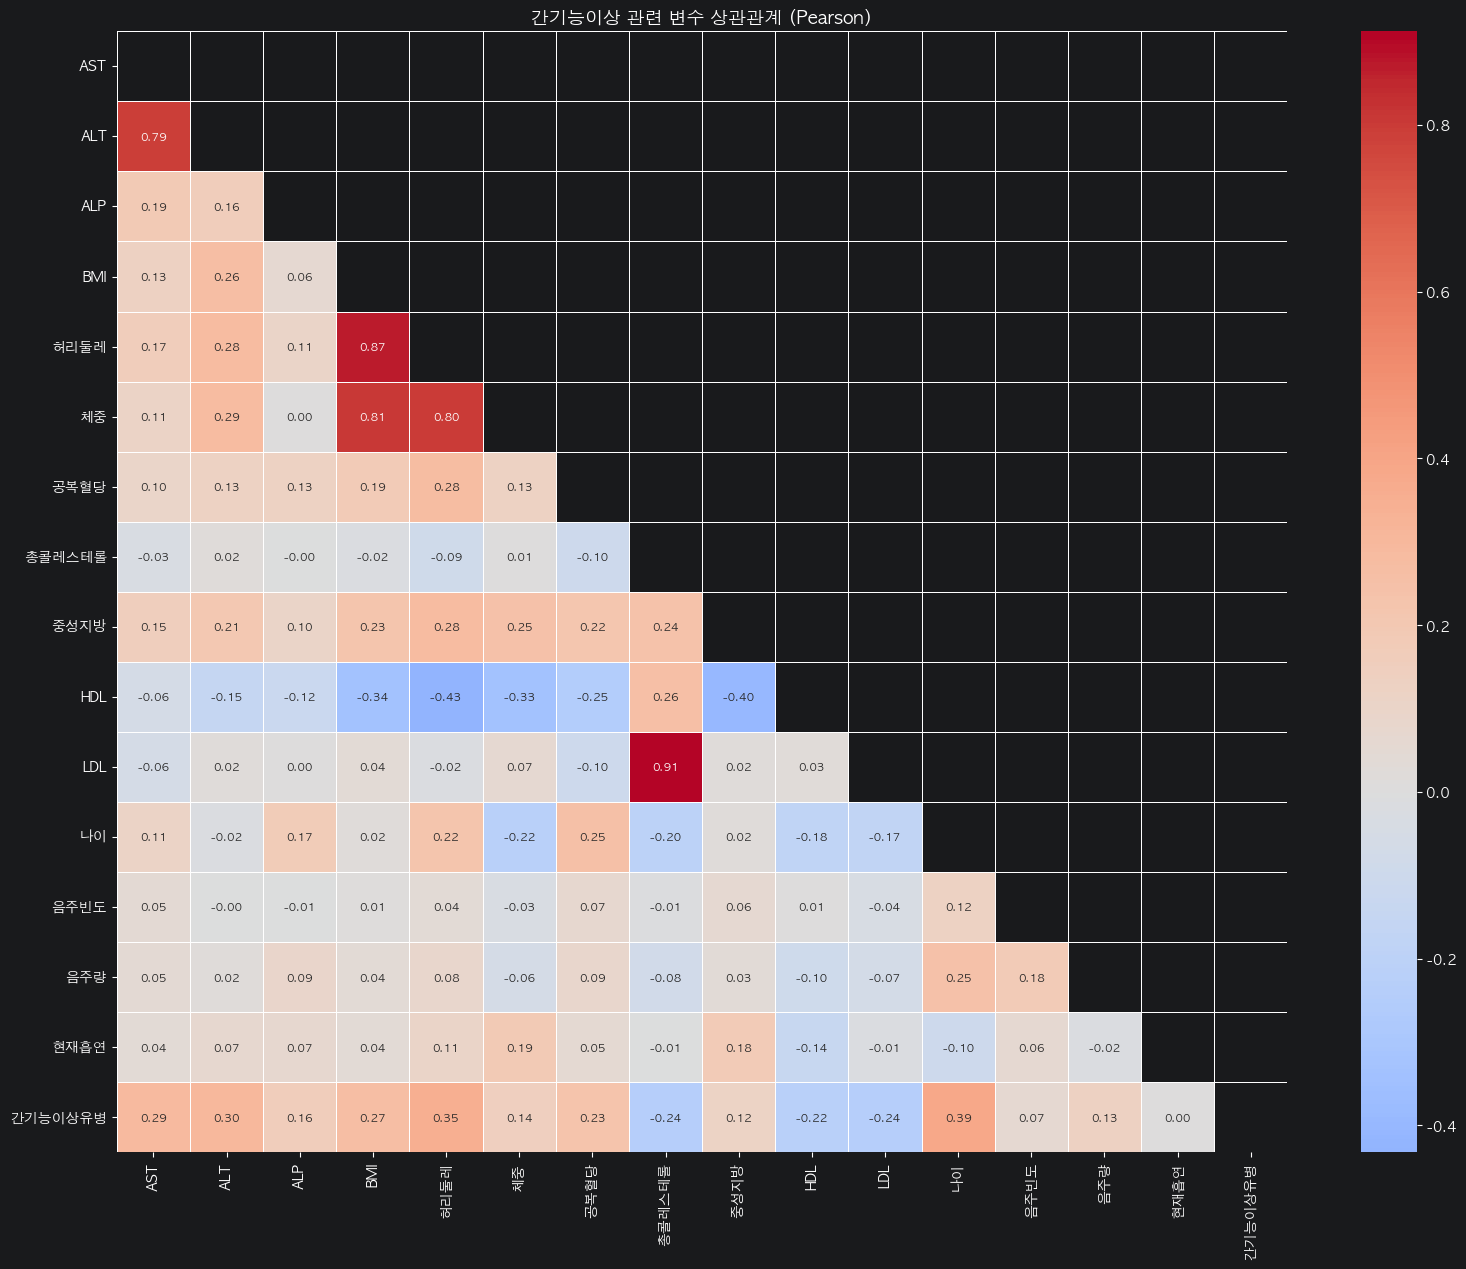


간기능이상유병 상관계수 상위 (절대값):
나이        0.390
허리둘레      0.353
ALT       0.300
AST       0.288
BMI       0.269
총콜레스테롤    0.240
LDL       0.236
공복혈당      0.231
HDL       0.222
ALP       0.162
체중        0.141
음주량       0.134
중성지방      0.118
음주빈도      0.067
현재흡연      0.001
Name: 간기능이상유병, dtype: float64


In [37]:
corr_candidates = [
    "AST","ALT","GGT","ALP",
    "BMI","허리둘레","체중",
    "공복혈당","총콜레스테롤","중성지방","HDL","LDL",
    "나이","음주빈도","음주량","현재흡연",
    "간기능이상유병"
]
corr_cols = [c for c in corr_candidates if c in df.columns]

if len(corr_cols) >= 3:
    corr = df[corr_cols].corr()
    fig, ax = plt.subplots(figsize=(max(8, len(corr_cols)), max(6, len(corr_cols)*0.8)))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
                center=0, ax=ax, annot_kws={"size":8}, linewidths=0.5)
    ax.set_title("간기능이상 관련 변수 상관관계 (Pearson)", fontsize=13)
    plt.tight_layout(); plt.show()

    if "간기능이상유병" in corr.columns:
        liver_corr = corr["간기능이상유병"].drop("간기능이상유병").abs().sort_values(ascending=False)
        print("\n간기능이상유병 상관계수 상위 (절대값):")
        print(liver_corr.round(3))

## 16. 전처리 및 통합 CSV 저장 (v3)
> 기존 타겟 3종 + **간기능이상유병** 추가 저장

In [38]:
import os

SAVE_DIR = DATA_DIR
SAVE_PATH_V3 = os.path.join(SAVE_DIR, "hn_all_preprocessed_v3.csv")

df_pp = df.copy()

# ── 직업 OHE ─────────────────────────────────────────────────────
occp_map = {1:"관리전문",2:"사무",3:"서비스판매",4:"농림어업",5:"기능노무",6:"주부학생",7:"무직"}
for key, label in occp_map.items():
    df_pp[f"직업_{label}"] = (df_pp["직업"] == key).astype(int)
df_pp["직업_작업미상"] = (df_pp["직업"].notna() & ~df_pp["직업"].isin(occp_map.keys())).astype(int)
df_pp = df_pp.drop(columns=["직업"])

# ── 컬럼 정리 ──────────────────────────────────────────────────────
target_cols = ["고혈압유병","당뇨유병","이상지질혈증유병","간기능이상유병"]
drop_cols   = [c for c in ["비만단계","연도","연령대"] if c in df_pp.columns]
feature_cols = [c for c in df_pp.columns if c not in target_cols + drop_cols]

df_v3 = df_pp[feature_cols + target_cols].copy()
df_v3.to_csv(SAVE_PATH_V3, index=False, encoding="utf-8-sig")

print(f"[v3 저장 완료] {SAVE_PATH_V3}")
print(f"shape: {df_v3.shape}")
print("\n타겟 분포:")
for col in target_cols:
    if col in df_v3.columns:
        vc = df_v3[col].value_counts(dropna=False)
        n0 = int(vc.get(0, 0)); n1 = int(vc.get(1, 0))
        nan = int(df_v3[col].isna().sum())
        ratio = f"1:{n0/n1:.1f}" if n1 > 0 else "N/A"
        print(f"  {col}: 정상={n0:,} / 유병={n1:,} / NaN={nan:,} / 불균형 {ratio}")

print("\n컬럼 목록:")
for c in df_v3.columns:
    print(f"  {c}")

[v3 저장 완료] /Users/admin/PycharmProjects/AH_03_03/etc/ml/ai_worker/data/hn_all_preprocessed_v3.csv
shape: (22255, 43)

타겟 분포:
  고혈압유병: 정상=14,162 / 유병=7,774 / NaN=319 / 불균형 1:1.8
  당뇨유병: 정상=15,880 / 유병=6,318 / NaN=57 / 불균형 1:2.5
  이상지질혈증유병: 정상=14,615 / 유병=6,942 / NaN=698 / 불균형 1:2.1
  간기능이상유병: 정상=12,974 / 유병=9,281 / NaN=0 / 불균형 1:1.4

컬럼 목록:
  성별
  나이
  간질환진단
  음주빈도
  음주량
  현재흡연
  걷기일수
  근력운동일수
  고혈압가족력_부
  고혈압가족력_모
  고혈압가족력_형제
  고지혈증가족력_부
  고지혈증가족력_모
  고지혈증가족력_형제
  당뇨가족력_부
  당뇨가족력_모
  당뇨가족력_형제
  키
  체중
  허리둘레
  BMI
  공복혈당
  총콜레스테롤
  HDL
  중성지방
  LDL
  AST
  ALT
  B형간염항원
  C형간염항체
  ALP
  직업_관리전문
  직업_사무
  직업_서비스판매
  직업_농림어업
  직업_기능노무
  직업_주부학생
  직업_무직
  직업_작업미상
  고혈압유병
  당뇨유병
  이상지질혈증유병
  간기능이상유병


## 17. EDA 요약

In [39]:
print("=" * 65)
print("EDA 요약 (v3)")
print("=" * 65)
print(f"총 샘플 수     : {len(df_v3):,}")
print(f"총 컬럼 수     : {len(df_v3.columns)}")
print()
for col in target_cols:
    if col in df_v3.columns:
        n1 = int(df_v3[col].sum())
        n0 = len(df_v3) - n1
        print(f"[{col}] 양성 {n1:,}명 ({n1/len(df_v3)*100:.1f}%) / 불균형 1:{n0/max(n1,1):.0f}")
print("=" * 65)
print("다음 단계 체크리스트:")
print("  [ ] 결측률 30% 초과 피처 제외 여부 결정")
print("  [ ] 불균형 전략: class_weight='balanced' (시작점)")
print("  [ ] 모델: LightGBM — Stratified K-Fold 5")
print("  [ ] 평가: Recall → PR-AUC → ROC-AUC")
print("  [ ] Threshold 튜닝: 0.3~0.4 범위 검토")
print("=" * 65)

EDA 요약 (v3)
총 샘플 수     : 22,255
총 컬럼 수     : 43

[고혈압유병] 양성 7,774명 (34.9%) / 불균형 1:2
[당뇨유병] 양성 6,318명 (28.4%) / 불균형 1:3
[이상지질혈증유병] 양성 6,942명 (31.2%) / 불균형 1:2
[간기능이상유병] 양성 9,281명 (41.7%) / 불균형 1:1
다음 단계 체크리스트:
  [ ] 결측률 30% 초과 피처 제외 여부 결정
  [ ] 불균형 전략: class_weight='balanced' (시작점)
  [ ] 모델: LightGBM — Stratified K-Fold 5
  [ ] 평가: Recall → PR-AUC → ROC-AUC
  [ ] Threshold 튜닝: 0.3~0.4 범위 검토
